# Bitcoin price forecast with LSTM
https://en.wikipedia.org/wiki/Long_short-term_memory

In [ ]:
import math
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam
from datetime import datetime, timedelta

## Load Bitcoin Prices

In [37]:
df = yf.download('BTC-USD', start='2020-01-01', end='2025-05-16')
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
...,...,...,...,...,...
2025-05-11,104106.359375,104937.992188,103364.742188,104701.070312,46285517406
2025-05-12,102812.953125,105747.453125,100814.406250,104106.960938,63250475404


In [38]:
df_close = df[('Close', 'BTC-USD')].to_frame(name='Close')
df_close

,Close
Date,
2020-01-01,7200.174316
2020-01-02,6985.470215
2020-01-03,7344.884277
2020-01-04,7410.656738
2020-01-05,7411.317383
...,...
2025-05-11,104106.359375
2025-05-12,102812.953125
2025-05-13,104169.812500


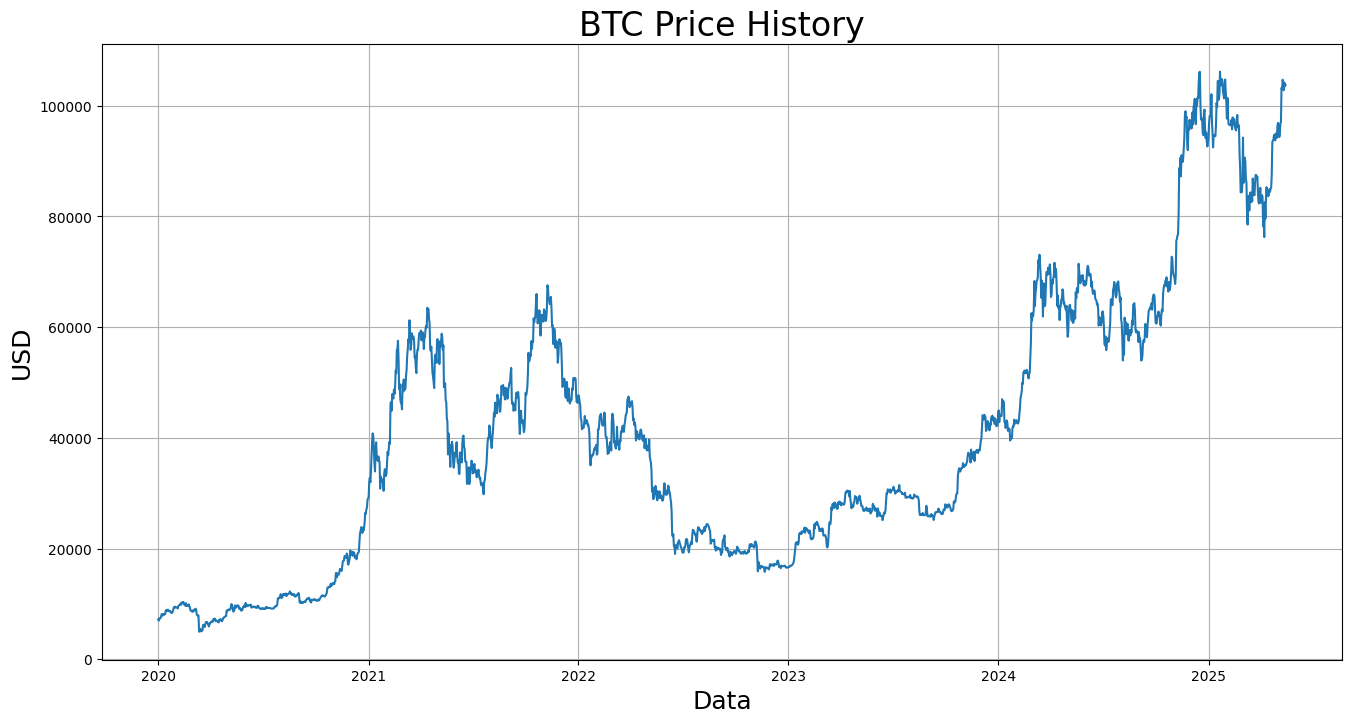

In [39]:
plt.figure(figsize=(16,8))
plt.title('BTC Price History', fontsize=24)
plt.plot(df_close['Close'])
plt.xlabel('Data', fontsize=18)
plt.ylabel('USD', fontsize=18)
plt.grid(True)
plt.show()

## Prepare data

In [40]:
# Number of days to look back
lookback = 30

# Create a DF with only close price
data = df_close.filter(['Close'])

# Convert the dataframe to numpy array
dataset = data.values

# Reserve 80% to train
training_data_len = math.ceil(len(dataset) * .8) # We are using %80 of the data for training
training_data_len

# Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Training dataset
train_data = scaled_data[0:training_data_len, :]

# Split the data into X_train and y_train data sets
X_train = []
y_train = []

for i in range(lookback, len(train_data)):
  X_train.append(train_data[i-lookback: i, 0])
  y_train.append(train_data[i, 0])

# Convert the X_train and y_train to numpy array
X_train, y_train = np.array(X_train), np.array(y_train)


# Reshape the data for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

# Create the testing dataset
test_data = scaled_data[training_data_len - lookback : , :]

# Create the dataset X_test and y_test
X_test = []
y_test = dataset[training_data_len : , :]
for i in range(lookback, len(test_data)):
  X_test.append(test_data[i-lookback : i, 0])


# Convert the data to a numpy array 
X_test = np.array(X_test)

# Reshape the test data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [41]:
# Check weights
min_value = scaler.data_min_[0]
max_value = scaler.data_max_[0]

print(f"Min: {min_value}, Max: {max_value}")

Min: 4970.7880859375, Max: 106146.265625


## Build LSTM Model

In [ ]:
# Build LSTM model
tf.random.set_seed(42)

patience = 200
epochs = 200
min_improvement = 0.01

model = Sequential([
  Input(shape=(X_train.shape[1], 1)),
  LSTM(60, activation='tanh', return_sequences=True),
  LSTM(60, activation='tanh', return_sequences=False),
  Dense(25),
  Dense(1)
])

optimizer = Adam(learning_rate=0.0027)

# Compile the model
model.compile(optimizer, loss='mean_squared_error')

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 60)         │        14,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60)             │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,471 (177.62 KB)

 Trainable params: 45,471 (177.62 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Train the model
callback = tf.keras.callbacks.EarlyStopping(
  monitor='loss',
  patience=patience,
  restore_best_weights=True,
  min_delta=min_improvement
)
history = model.fit(X_train, y_train, batch_size=1, epochs=epochs, callbacks=[callback], verbose=1)

Epoch 1/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0022
Epoch 2/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5.6313e-04
Epoch 3/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5.0867e-04
Epoch 4/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5.2028e-04
Epoch 5/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5.0376e-04
Epoch 6/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 4.5660e-04
Epoch 7/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 4.2798e-04
Epoch 8/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 4.0749e-04
Epoch 9/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.7522e-04
Epoch 10/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 3.5860e-04
Epoch 11/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.4625e-04
Epoch 12/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 3.4219e-04
Epoch 13/200
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.3771e-04
Epoch 14/200
1540/1540 ━━━━━━━━━━━━━━━

## Epochs vs Loss

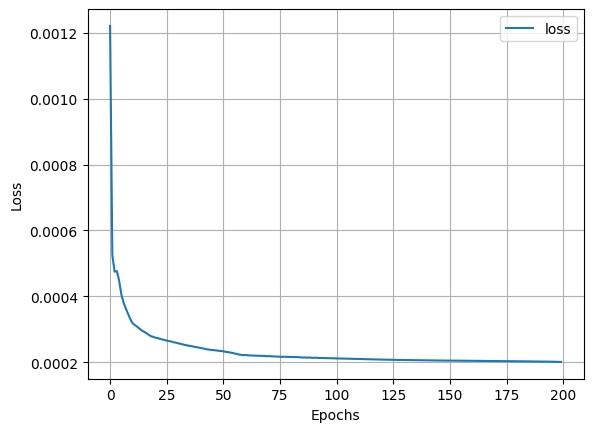

In [44]:
historyPlot = pd.DataFrame(history.history)
historyPlot.plot()
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid(True)

## Compare real price with predicted price

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


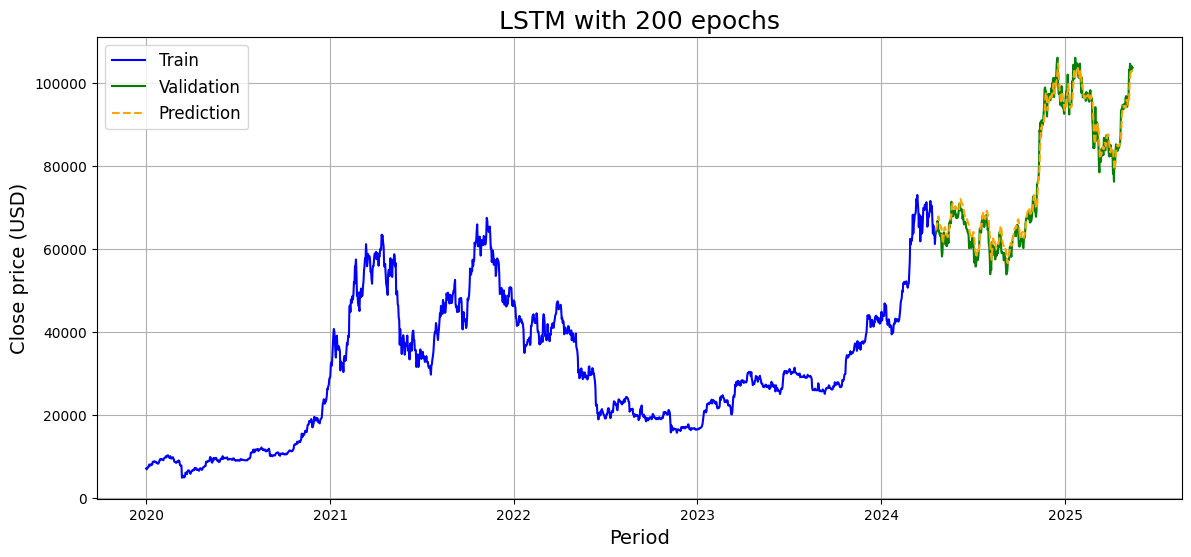

In [ ]:
# Predictions values
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Split data into train and validation
train = data[:training_data_len].copy()
valid = data[training_data_len:].copy()

# Add prediction to validation dataframe
valid['Predictions'] = predictions

plt.figure(figsize=(14, 6))
plt.title(f'LSTM with {len(history.history["loss"])} epochs', fontsize=18)
plt.xlabel('Period', fontsize=14)
plt.ylabel('Close price (USD)', fontsize=14)
plt.plot(train['Close'], label='Train', color='blue')
plt.plot(valid['Close'], label='Validation', color='green')
plt.plot(valid['Predictions'], label='Prediction', color='orange', linestyle='--')
plt.legend(['Train', 'Validation', 'Prediction'], loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

In [46]:
y_view = y_test.reshape(-1, 1)
predictions_view = scaler.inverse_transform(predictions)

comparison_df = pd.DataFrame({
    'Real': y_test.flatten(),
    'Predicted': predictions.flatten()
})


print(comparison_df.tail(10))

              Real      Predicted
382   96802.476562   94806.937500
383   97032.320312   95562.539062
384  103241.460938   96258.796875
385  102970.851562   99401.335938
386  104696.328125  101309.562500
387  104106.359375  102912.085938
388  102812.953125  103379.578125
389  104169.812500  102831.023438
390  103539.414062  102955.218750
391  103744.640625  102803.632812


## Predicted price for the next 10 days

In [ ]:
# Number of days to predict
future_days = 10
days = 30
last_x_days = data[-days:].values

print("Shape of last_x_days:", last_x_days.shape) 

# Scale the data using the same scaler used for training
last_x_days_scaled = scaler.transform(last_x_days)
print("Shape of last_x_days_scaled:", last_x_days_scaled.shape) 

# List to store scaled predictions
future_predictions_scaled = []

# Initial array with the last X days scaled
current_input = last_x_days_scaled
print("Initial shape of current_input:", current_input.shape)

# Generate predictions for the next days
for i in range(future_days):
  # Reshape to the format expected by the model
  current_input_reshaped = np.reshape(current_input, (1, current_input.shape[0], 1))

  # Predict the next day
  next_pred_scaled = model.predict(current_input_reshaped, verbose=0)

  # Store the prediction
  future_predictions_scaled.append(next_pred_scaled[0, 0])

  # Update the input window: remove the oldest day and add the prediction
  next_pred_scaled = next_pred_scaled.reshape(1, 1)  # Ensure shape is (1, 1)
  current_input = np.append(current_input[1:], next_pred_scaled, axis=0)

# Convert scaled predictions back to real prices
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Use today's date as the starting point
today = datetime.now()

# Create future dates starting from today
future_dates = [today + timedelta(days=i) for i in range(future_days)]

# Create a DataFrame with dates and predicted prices
future_df = pd.DataFrame({
  'Date': future_dates,
  'Predicted Value': future_predictions.flatten()
})
future_df.set_index('Date', inplace=True)

# Display predictions
print(f"\nBitcoin price forecast for the next {future_days} days:")
for date, price in zip(future_dates, future_predictions.flatten()):
  formatted_date = date.strftime('%Y-%m-%d')
  print(f"Date: {formatted_date} - Predicted Price: ${price:.2f}")

Shape of last_x_days: (30, 1)
Shape of last_x_days_scaled: (30, 1)
Initial shape of current_input: (30, 1)

Bitcoin price forecast for the next 10 days:
Date: 2025-05-16 - Predicted Price: $102788.77
Date: 2025-05-17 - Predicted Price: $102381.34
Date: 2025-05-18 - Predicted Price: $101947.04
Date: 2025-05-19 - Predicted Price: $101533.27
Date: 2025-05-20 - Predicted Price: $101153.18
Date: 2025-05-21 - Predicted Price: $100809.13
Date: 2025-05-22 - Predicted Price: $100499.20
Date: 2025-05-23 - Predicted Price: $100219.70
Date: 2025-05-24 - Predicted Price: $99966.29
Date: 2025-05-25 - Predicted Price: $99734.70


## Save model

In [ ]:
# model.save('../saved-models/bitcoin-lstm-model.keras')